In [1]:
import os

REPO_PATH = '/content/code'
REPO_URL = 'https://github.com/Laio95/aml-2025-mistake-detection.git'

if os.path.exists(REPO_PATH):
    print(f"Repository found in {REPO_PATH}. Updating...")
    %cd {REPO_PATH}
    !git pull
    !git submodule update --init --recursive
else:
    print(f"Cloning repository into {REPO_PATH}...")
    !git clone --recursive {REPO_URL} {REPO_PATH}

%cd {REPO_PATH}

Cloning repository into /content/code...
Cloning into '/content/code'...
remote: Enumerating objects: 646, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 646 (delta 164), reused 179 (delta 137), pack-reused 415 (from 2)
Receiving objects: 100% (646/646), 5.03 MiB | 2.79 MiB/s, done.
Resolving deltas: 100% (397/397), done.
Submodule 'actionformer_release' (https://github.com/rohithpeddi/actionformer_release.git) registered for path 'actionformer_release'
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/actionformer_release'...
remote: Enumerating objects: 410, done.        
remote: Counting objects: 100% (26/26), done.        
remote: Compressing objects: 100% (20/20), done.        
remote: Total 410 (delta 16), reused 6 (delta 6), pack-reused 384 (from 2)        
Receiving objects: 100% (410/410), 651.07 KiB | 5.17 MiB/s, done.
Resolv

version

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# 1. Install base dependencies
!pip install -r /content/code/requirements.txt
!pip install PyYAML pandas h5py joblib tensorboard ninja pytorchvideo

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
     ━━━━━━━━━━━━━━━━━━

In [ ]:
# 2. Compile C++ extension for NMS
import os
import sys

# --- SUBMODULE PATH ---
# Assuming actionformer is a submodule inside /content/code
SUBMODULE_PATH = "/content/code/actionformer_release"
UTILS_PATH = os.path.join(SUBMODULE_PATH, "libs/utils")

if not os.path.exists(UTILS_PATH):
    print(f"Error: Could not find {UTILS_PATH}. Check the submodule path!")
else:
    %cd {UTILS_PATH}

    # Deep clean
    !rm -rf build/
    !rm -f nms_1d_cpu*.so
    !rm -f nms_1d_cuda*.so

    # Build INPLACE
    !python setup.py build_ext --inplace

    # 3. Quick check
    print("\n--- Compiled files check ---")
    compiled_files = [f for f in os.listdir('.') if f.endswith('.so')]
    if compiled_files:
        for f in compiled_files:
            print(f"Found: {f}")
    else:
        print("Error: No .so files generated. Check the logs above for compilation errors.")

# 4. UPDATE PYTHONPATH (required)
# Add repo root and utils folder to sys.path
os.environ['PYTHONPATH'] = f"/content/code:{UTILS_PATH}:" + os.environ.get('PYTHONPATH', '')

# Return to step1 folder
%cd /content/code/extension/step1

/content/code/actionformer_release/libs/utils
running build_ext
building 'nms_1d_cpu' extension
creating /content/code/actionformer_release/libs/utils/build/temp.linux-x86_64-cpython-312/csrc
[1/1] c++ -MMD -MF /content/code/actionformer_release/libs/utils/build/temp.linux-x86_64-cpython-312/csrc/nms_cpu.o.d -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/local/lib/python3.12/dist-packages/torch/include -I/usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -I/usr/include/python3.12 -c -c /content/code/actionformer_release/libs/utils/csrc/nms_cpu.cpp -o /content/code/actionformer_release/libs/utils/build/temp.linux-x86_64-cpython-312/csrc/nms_cpu.o -fopenmp -DTORCH_API_INCLUDE_EXTENSION_H -DTORCH_EXTENSION_NAME=nms_1d_cpu -std=c++17
creating build/lib.linux-x86_64-cpython-312
x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-

In [7]:
%cd /content/code/extension/step1

!python train.py captaincook_egovlp.yaml \
    --backbone egovlp \
    --division_type recordings \
    --output reproduce

# num_frames = 30 by default

/content/code/extension/step1
2026-05-06 11:09:31.261708: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
{'dataset': {'backbone': 'egovlp',
             'crop_ratio': [0.9, 1.0],
             'default_fps': 29.97,
             'division_type': 'recordings',
             'downsample_rate': 1,
             'feat_folder': '/content/drive/MyDrive/AML_Project/CaptainCook4D/features_egovlp_num_frames_4',
             'feat_stride': 30,
             'file_ext': '.npz',
             'file_prefix': None,
             'file_suffix': '_360p',
             'force_upsampling': False,
             'input_dim': 256,
             'json_file': 'combined_recordings.json',
             'max_seq_len': 4096,
             'num_classes': 353,
             'num_frames'

In [8]:
import os

# 1. Define paths
# YAML config used for training
CONFIG_FILE = "captaincook_egovlp.yaml"

# Path to the checkpoint directory
CHECKPOINT_DIR = "/content/drive/MyDrive/AML_Project/step1/checkpoints"

# Find the latest checkpoint (or the one you want to evaluate)
# To use the latest epoch:
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "epoch_021.pth.tar")

# 2. Navigate to the correct directory
%cd /content/code/extension/step1

# 3. Run evaluation
# Note: uses the 'test' split as defined in the YAML
%cd /content/code/extension/step1

# If training used --output reproduce
!python eval.py captaincook_egovlp.yaml reproduce \
  --backbone egovlp \
  --saveonly \
  --all_splits

/content/code/extension/step1
/content/code/extension/step1
Checkpoint base path: /content/drive/MyDrive/AML_Project/step1/checkpoints/captaincook_dataset/egovlp_recordings_reproduce
{'dataset': {'backbone': 'egovlp',
             'crop_ratio': [0.9, 1.0],
             'default_fps': 29.97,
             'division_type': 'recordings',
             'downsample_rate': 1,
             'feat_folder': '/content/drive/MyDrive/AML_Project/CaptainCook4D/features_egovlp_num_frames_4',
             'feat_stride': 30,
             'file_ext': '.npz',
             'file_prefix': None,
             'file_suffix': '_360p',
             'force_upsampling': False,
             'input_dim': 256,
             'json_file': 'combined_recordings.json',
             'max_seq_len': 4096,
             'num_classes': 353,
             'num_frames': 30,
             'trunc_thresh': 0.3,
             'videos_type': 'all'},
 'dataset_name': 'captaincook_dataset',
 'devices': [0],
 'init_rand_seed': 1234567891,
 'l

1. DISTRIBUZIONE SCORE
  Detection totali nel pkl: 768000
  score >= 0.245:   5821  (0.8%)
  score >= 0.246:   5773  (0.8%)
  score >= 0.247:   5722  (0.7%)
  score >= 0.248:   5671  (0.7%)
  score >= 0.249:   5629  (0.7%)
  score >= 0.250:   5576  (0.7%)


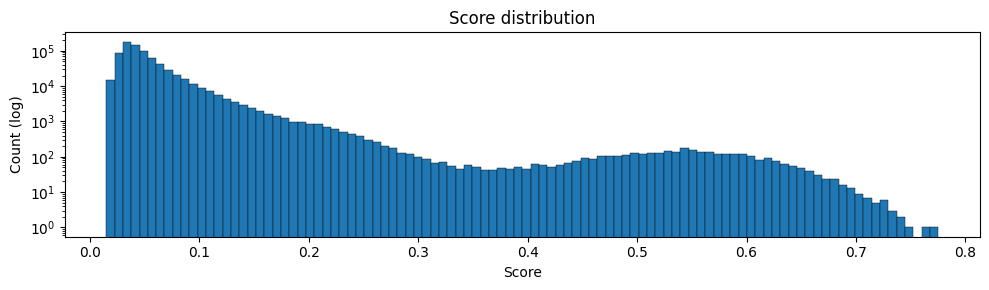


2. N_STEPS PREDETTI vs GROUND TRUTH
   Threshold |  Mean pred |  Mean GT |  Ratio
  -----------+------------+----------+-------
       0.245 |     15.159 |   14.844 |  1.021x
       0.246 |     15.034 |   14.844 |  1.013x
       0.247 |     14.901 |   14.844 |  1.004x
       0.248 |     14.768 |   14.844 |  0.995x
       0.249 |     14.659 |   14.844 |  0.988x
       0.250 |     14.521 |   14.844 |  0.978x

3. RECALL@0.5 A DIVERSI THRESHOLD
  score >= 0.245: Recall@0.5 = 0.7368
  score >= 0.246: Recall@0.5 = 0.7362
  score >= 0.247: Recall@0.5 = 0.7352
  score >= 0.248: Recall@0.5 = 0.7348
  score >= 0.249: Recall@0.5 = 0.7343
  score >= 0.250: Recall@0.5 = 0.7328

4. ISPEZIONE QUALITATIVA

Video: 1_19

Top-10 detection di ActionFormer (per score):
  [ 1] [ 490.8s –  559.6s]  dur= 68.8s  score=0.6348  label_id=5
  [ 2] [ 161.4s –  277.6s]  dur=116.2s  score=0.6229  label_id=12
  [ 3] [ 101.5s –  151.4s]  dur= 49.9s  score=0.6042  label_id=4
  [ 4] [ 279.4s –  310.2s]  dur= 30.8s  scor

In [5]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
PKL_PATH    = '/content/drive/MyDrive/AML_Project/step1/checkpoints/captaincook_dataset/egovlp_recordings_reproduce/eval_results.pkl'
STEP_EMB_DIR = '/content/drive/MyDrive/AML_Project/step1/step_embeddings'
GT_JSON     = '/content/code/extension/step1/combined_recordings.json'

# ─────────────────────────────────────────────────────────────────────────────
# 1. SCORE DISTRIBUTION
#    A well-trained model should produce few high-score proposals
#    and many low-score ones (long-tail distribution).
#    If scores are all near 0.001, the model is not discriminating.
# ─────────────────────────────────────────────────────────────────────────────
with open(PKL_PATH, 'rb') as f:
    raw = pickle.load(f)

scores = np.array(raw['score'])
print("=" * 55)
print("1. SCORE DISTRIBUTION")
print("=" * 55)
print(f"  Total detections in pkl: {len(scores)}")
for thr in [ 0.245, 0.246, 0.247, 0.248, 0.249, 0.25]:
    n = (scores >= thr).sum()
    print(f"  score >= {thr:.3f}: {n:6d}  ({100*n/len(scores):.1f}%)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(scores, bins=100, log=True, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Score'); ax.set_ylabel('Count (log)'); ax.set_title('Score distribution')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2. PREDICTED N_STEPS vs GROUND TRUTH
#    Per video: number of GT steps vs ActionFormer predictions at different thresholds.
#
# ─────────────────────────────────────────────────────────────────────────────
with open(GT_JSON) as f:
    gt_db = json.load(f)['database']

# Group detections by video
dets_by_video = {}
for vid, ts, te, lab, sc in zip(
    raw['video-id'], raw['t-start'], raw['t-end'], raw['label'], raw['score']
):
    dets_by_video.setdefault(str(vid), []).append({
        't_start': float(ts), 't_end': float(te),
        'label_id': int(lab), 'score': float(sc)
    })

print("\n" + "=" * 55)
print("2. PREDICTED N_STEPS vs GROUND TRUTH")
print("=" * 55)

gt_counts, pred_counts = {}, {}
for vid_id, info in gt_db.items():
    gt_counts[vid_id] = len(info.get('annotations', []))

thresholds = [0.245, 0.246, 0.247, 0.248, 0.249, 0.25]
print(f"  {'Threshold':>10} | {'Mean pred':>10} | {'Mean GT':>8} | {'Ratio':>6}")
print(f"  {'-'*10}-+-{'-'*10}-+-{'-'*8}-+-{'-'*6}")
for thr in thresholds:
    preds = [
        sum(1 for d in dets if d['score'] >= thr)
        for vid, dets in dets_by_video.items()
    ]
    mean_pred = np.mean(preds)
    mean_gt   = np.mean([gt_counts.get(v, 0) for v in dets_by_video])
    print(f"  {thr:>10.3f} | {mean_pred:>10.3f} | {mean_gt:>8.3f} | {mean_pred/mean_gt:>6.3f}x")

# ─────────────────────────────────────────────────────────────────────────────
# 3. tIoU vs GROUND TRUTH
#    Per video, per GT step, find the detection with highest tIoU.
#    Recall@0.5: fraction of GT steps covered with tIoU >= 0.5
# ─────────────────────────────────────────────────────────────────────────────
def tiou(a, b):
    inter = max(0.0, min(a[1], b[1]) - max(a[0], b[0]))
    if inter == 0: return 0.0
    union = (a[1]-a[0]) + (b[1]-b[0]) - inter
    return inter / union if union > 0 else 0.0

print("\n" + "=" * 55)
print("3. RECALL@0.5 AT DIFFERENT THRESHOLDS")
print("=" * 55)

for thr in thresholds:
    recalls = []
    for vid_id, info in gt_db.items():
        gt_anns = info.get('annotations', [])
        if not gt_anns or vid_id not in dets_by_video:
            continue
        dets_filtered = [d for d in dets_by_video[vid_id] if d['score'] >= thr]
        if not dets_filtered:
            recalls.append(0.0)
            continue
        pred_ivs = [(d['t_start'], d['t_end']) for d in dets_filtered]
        gt_ivs   = [(a['segment'][0], a['segment'][1]) for a in gt_anns]
        best = [max(tiou(g, p) for p in pred_ivs) for g in gt_ivs]
        recalls.append(np.mean(np.array(best) >= 0.5))
    print(f"  score >= {thr:.3f}: Recall@0.5 = {np.mean(recalls):.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. QUALITATIVE INSPECTION ON A SAMPLE VIDEO
#    Compare top-10 detections (by score) with the GT of a sample video.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("4. QUALITATIVE INSPECTION")
print("=" * 55)

sample_vid = list(dets_by_video.keys())[0]
top_dets   = sorted(dets_by_video[sample_vid], key=lambda d: -d['score'])[:10]
gt_anns    = gt_db.get(sample_vid, {}).get('annotations', [])

print(f"\nVideo: {sample_vid}")
print(f"\nTop-10 ActionFormer detections (by score):")
for i, d in enumerate(top_dets):
    dur = d['t_end'] - d['t_start']
    print(f"  [{i+1:2d}] [{d['t_start']:6.1f}s – {d['t_end']:6.1f}s]  "
          f"dur={dur:5.1f}s  score={d['score']:.4f}  label_id={d['label_id']}")

print(f"\nGround truth steps ({len(gt_anns)} total):")
for i, a in enumerate(gt_anns):
    dur = a['segment'][1] - a['segment'][0]
    err = ' ← ERROR' if a.get('has_error') else ''
    print(f"  [{i+1:2d}] [{a['segment'][0]:6.1f}s – {a['segment'][1]:6.1f}s]  "
          f"dur={dur:5.1f}s  label='{a['label'][:35]}'{err}")



   Thr |  F1 no-fb |  F1 +fb |  Cov no-fb | Fallback | Dets/vid
-----------------------------------------------------------------
 0.100 |    0.7446 |  0.7446 |     100.0% |        0 |    133.0
 0.105 |    0.7513 |  0.7513 |     100.0% |        0 |    117.7
 0.110 |    0.7570 |  0.7570 |     100.0% |        0 |    104.8
 0.115 |    0.7629 |  0.7629 |     100.0% |        0 |     93.5
 0.120 |    0.7692 |  0.7692 |     100.0% |        0 |     83.9
 0.125 |    0.7757 |  0.7757 |     100.0% |        0 |     75.8
 0.130 |    0.7804 |  0.7804 |     100.0% |        0 |     68.5
 0.135 |    0.7848 |  0.7848 |     100.0% |        0 |     62.5
 0.140 |    0.7905 |  0.7905 |     100.0% |        0 |     57.1
 0.145 |    0.7951 |  0.7951 |     100.0% |        0 |     52.5
 0.150 |    0.7987 |  0.7987 |     100.0% |        0 |     48.3
 0.155 |    0.8010 |  0.8010 |     100.0% |        0 |     44.6
 0.160 |    0.8027 |  0.8027 |     100.0% |        0 |     41.5
 0.165 |    0.8056 |  0.8056 |     100

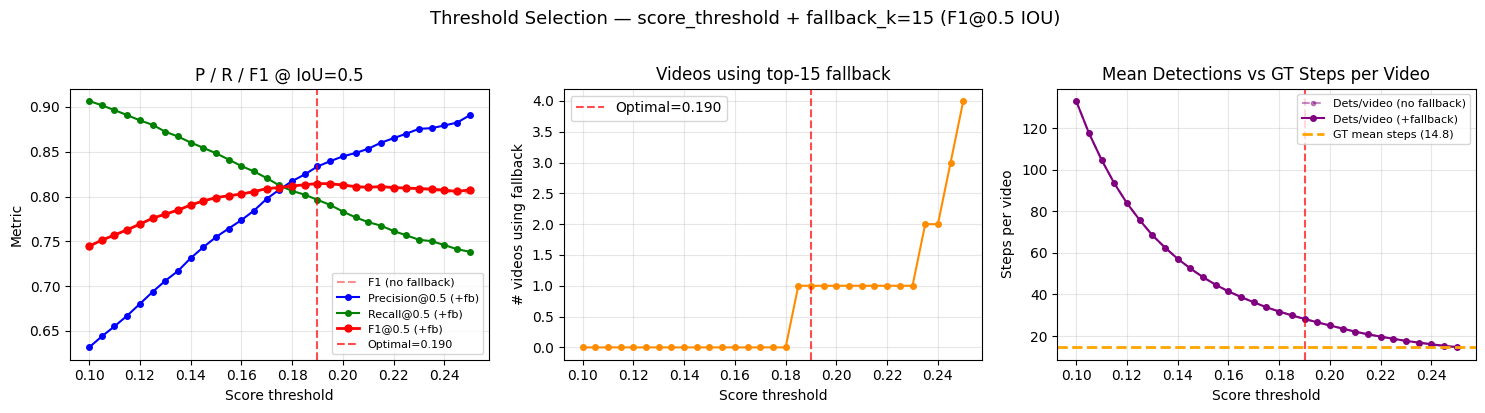

In [12]:
# ── Threshold selection with fallback_k=15: maximize F1@0.5 IOU ─────────────
# Strategy: score_threshold filters detections globally.
# Videos with no detection above threshold fall back to their top-fallback_k
# proposals by score — guaranteeing 100% coverage for ALL thresholds.
#
# We compare side-by-side:
#   WITHOUT fallback: videos below threshold excluded (coverage < 100%)
#   WITH fallback k=15: those videos use top-15 → coverage always 100%
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pickle, json

PKL_PATH = '/content/drive/MyDrive/AML_Project/step1/checkpoints/captaincook_dataset/egovlp_recordings_reproduce/eval_results.pkl'
GT_JSON  = '/content/code/extension/step1/combined_recordings.json'

with open(PKL_PATH, 'rb') as f:
    raw = pickle.load(f)
with open(GT_JSON) as f:
    gt_db = json.load(f)['database']

# ── Group all detections per video as numpy arrays ────────────────────────────
all_by_video = {}
for vid, ts, te, sc in zip(raw['video-id'], raw['t-start'], raw['t-end'], raw['score']):
    d = all_by_video.setdefault(str(vid), {'t_start': [], 't_end': [], 'score': []})
    d['t_start'].append(float(ts))
    d['t_end'].append(float(te))
    d['score'].append(float(sc))
for vid in all_by_video:
    all_by_video[vid] = {k: np.array(v) for k, v in all_by_video[vid].items()}

# ── Precompute IoU matrix (N_gt, N_pred) per video — done ONCE ───────────────
mean_gt = np.mean([len(info.get('annotations', [])) for info in gt_db.values()
                   if info.get('annotations')])

video_data = {}
for vid_id, info in gt_db.items():
    gt_anns = info.get('annotations', [])
    if not gt_anns or vid_id not in all_by_video:
        continue
    gt_s = np.array([a['segment'][0] for a in gt_anns])[:, None]
    gt_e = np.array([a['segment'][1] for a in gt_anns])[:, None]
    d    = all_by_video[vid_id]
    pr_s = d['t_start'][None, :]
    pr_e = d['t_end'][None, :]
    inter = np.maximum(0, np.minimum(gt_e, pr_e) - np.maximum(gt_s, pr_s))
    union = (gt_e - gt_s) + (pr_e - pr_s) - inter
    video_data[vid_id] = {
        'iou':    np.where(union > 0, inter / union, 0.0),
        'scores': d['score'],
        'n_gt':   len(gt_anns),
    }

# ── Sweep thresholds [0.10, 0.25] — with and without fallback ────────────────
FALLBACK_K = 15
thresholds = np.round(np.arange(0.10, 0.255, 0.005), 3)
records_no_fb, records_fb = [], []

for thr in thresholds:
    for use_fallback in [False, True]:
        precisions, recalls, n_dets_list = [], [], []
        n_covered, n_fallback_used = 0, 0

        for vid_id, vd in video_data.items():
            mask  = vd['scores'] >= thr
            n_det = int(mask.sum())

            if n_det == 0 and use_fallback:
                top_idx = np.argsort(vd['scores'])[-FALLBACK_K:]
                mask = np.zeros(len(vd['scores']), dtype=bool)
                mask[top_idx] = True
                n_det = int(mask.sum())
                n_fallback_used += 1

            n_dets_list.append(n_det)

            if n_det > 0:
                n_covered += 1
                iou_sub = vd['iou'][:, mask]
                recalls.append(   float((iou_sub.max(axis=1) >= 0.5).mean()))
                precisions.append(float((iou_sub.max(axis=0) >= 0.5).mean()))
            else:
                recalls.append(0.0)

        mean_p = float(np.mean(precisions)) if precisions else 0.0
        mean_r = float(np.mean(recalls))
        f1     = 2*mean_p*mean_r / (mean_p + mean_r) if (mean_p + mean_r) > 0 else 0.0

        rec = {'thr': thr, 'precision': mean_p, 'recall': mean_r, 'f1': f1,
               'coverage': n_covered / len(video_data),
               'mean_dets': float(np.mean(n_dets_list)),
               'n_fallback': n_fallback_used}
        (records_fb if use_fallback else records_no_fb).append(rec)

# ── Optimal threshold (with fallback → always 100% coverage) ─────────────────
optimal = max(records_fb, key=lambda r: r['f1'])

# ── Print comparison table ────────────────────────────────────────────────────
print(f"{'Thr':>6} | {'F1 no-fb':>9} | {'F1 +fb':>7} | {'Cov no-fb':>10} | {'Fallback':>8} | {'Dets/vid':>8}")
print("-" * 65)
for r0, r1 in zip(records_no_fb, records_fb):
    mark = "  ◄ OPTIMAL" if r1['thr'] == optimal['thr'] else ""
    print(f"{r1['thr']:>6.3f} | {r0['f1']:>9.4f} | {r1['f1']:>7.4f} | "
          f"{r0['coverage']*100:>9.1f}% | {r1['n_fallback']:>8d} | {r1['mean_dets']:>8.1f}{mark}")

print(f"\n→ Optimal (fallback_k={FALLBACK_K}): thr={optimal['thr']:.3f}")
print(f"  F1@0.5    : {optimal['f1']:.4f}")
print(f"  Prec@0.5  : {optimal['precision']:.4f}")
print(f"  Rec@0.5   : {optimal['recall']:.4f}")
print(f"  Coverage  : 100.0%  ({optimal['n_fallback']} videos used fallback)")
print(f"  Dets/video: {optimal['mean_dets']:.1f}  (GT mean: {mean_gt:.1f})")

# ── Plots ─────────────────────────────────────────────────────────────────────
thrs = [r['thr'] for r in records_fb]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(thrs, [r['f1']        for r in records_no_fb], 'r--', ms=3, alpha=0.45, label='F1 (no fallback)')
ax.plot(thrs, [r['precision'] for r in records_fb],    'b-o', ms=4, label='Precision@0.5 (+fb)')
ax.plot(thrs, [r['recall']    for r in records_fb],    'g-o', ms=4, label='Recall@0.5 (+fb)')
ax.plot(thrs, [r['f1']        for r in records_fb],    'r-o', ms=5, lw=2, label='F1@0.5 (+fb)')
ax.axvline(optimal['thr'], color='r', ls='--', alpha=0.7, label=f"Optimal={optimal['thr']:.3f}")
ax.set_xlabel('Score threshold'); ax.set_ylabel('Metric')
ax.set_title('P / R / F1 @ IoU=0.5')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(thrs, [r['n_fallback'] for r in records_fb], color='darkorange', marker='o', ms=4)
ax.axvline(optimal['thr'], color='r', ls='--', alpha=0.7, label=f"Optimal={optimal['thr']:.3f}")
ax.set_xlabel('Score threshold'); ax.set_ylabel('# videos using fallback')
ax.set_title(f'Videos using top-{FALLBACK_K} fallback')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(thrs, [r['mean_dets'] for r in records_no_fb], 'purple', ls='--', marker='o', ms=3, alpha=0.45, label='Dets/video (no fallback)')
ax.plot(thrs, [r['mean_dets'] for r in records_fb],    'purple', marker='o', ms=4,           label='Dets/video (+fallback)')
ax.axhline(mean_gt, color='orange', ls='--', lw=2, label=f'GT mean steps ({mean_gt:.1f})')
ax.axvline(optimal['thr'], color='r', ls='--', alpha=0.7)
ax.set_xlabel('Score threshold'); ax.set_ylabel('Steps per video')
ax.set_title('Mean Detections vs GT Steps per Video')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'Threshold Selection — score_threshold + fallback_k={FALLBACK_K} (F1@0.5 IOU)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [10]:
%cd /content/code/extension/step1

PKL_PATH    = '/content/drive/MyDrive/AML_Project/step1/checkpoints/captaincook_dataset/egovlp_recordings_reproduce/eval_results.pkl'
FEAT_FOLDER = '/content/drive/MyDrive/AML_Project/CaptainCook4D/features_egovlp_num_frames_4'
OUTPUT_DIR  = '/content/drive/MyDrive/AML_Project/step1/step_embeddings'

!python build_step_embeddings.py \
    --pkl        "{PKL_PATH}" \
    --feat_folder "{FEAT_FOLDER}" \
    --output_dir  "{OUTPUT_DIR}" \
    --file_suffix "_360p" \
    --file_ext    ".npz" \
    --score_threshold 0.180  \
    --verify


/content/code/extension/step1
Loaded 12200/768000 detections (score >= 0.18) across 384 videos.
  [50/384] 16_26: 49 steps → 16_26_step_embeddings.npz
  [100/384] 22_4: 39 steps → 22_4_step_embeddings.npz
  [150/384] 28_26: 37 steps → 28_26_step_embeddings.npz
  [200/384] 8_33: 14 steps → 8_33_step_embeddings.npz
  [250/384] 26_19: 48 steps → 26_19_step_embeddings.npz
  [300/384] 16_42: 25 steps → 16_42_step_embeddings.npz
  [350/384] 28_24: 20 steps → 28_24_step_embeddings.npz
  [384/384] 9_108: 11 steps → 9_108_step_embeddings.npz

Done. Saved 384/384 step embedding files in '/content/drive/MyDrive/AML_Project/step1/step_embeddings'.

Verification (3 samples):
  10_16_step_embeddings.npz
    step_embeddings : (48, 256)  (mean norm: 26.522)
    step_intervals  : (48, 2)  (t range: [0.3s – 963.2s])
  10_18_step_embeddings.npz
    step_embeddings : (29, 256)  (mean norm: 25.720)
    step_intervals  : (29, 2)  (t range: [6.0s – 517.8s])
  10_24_step_embeddings.npz
    step_embeddings : (

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. FINAL CHECK: .npz file integrity
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("5. .npz FILE INTEGRITY")
print("=" * 55)

npz_files = sorted(Path(STEP_EMB_DIR).glob('*.npz'))
print(f"  .npz files produced: {len(npz_files)}")
print(f"  File GT nel JSON:   {len(gt_db)}")
print(f"  Coverage:           {len(npz_files)/len(gt_db)*100:.1f}%")

sample_npz = np.load(npz_files[0], allow_pickle=True)
print(f"\n  Esempio: {npz_files[0].name}")
for key in sample_npz.files:
    arr = sample_npz[key]
    print(f"    {key}: shape={getattr(arr, 'shape', '(scalar)')}  dtype={getattr(arr, 'dtype', type(arr))}")


5. INTEGRITÀ FILE .npz
  File .npz prodotti: 384
  File GT nel JSON:   384
  Coverage:           100.0%

  Esempio: 10_16_step_embeddings.npz
    step_embeddings: shape=(48, 256)  dtype=float32
    step_intervals: shape=(48, 2)  dtype=float32
    step_ids: shape=(48,)  dtype=int32
    step_scores: shape=(48,)  dtype=float32
    recording_id: shape=()  dtype=<U5
